# Projeto Visão Computacional: Detecção de Câncer de Mama em Mamografias com CNN

Este projeto utiliza Redes Neurais Convulsionais para classificar imagens de mamografia entre Benigno e Maligno. Utilizamos o dataset CBIS-DDSM.

Link: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset

# 1. Configuração e Download dos Dados

Obs: Para que o download do dataset do Kaggle possa seguir é preciso habilitar uma "chave" no secrets do Colab. A chave deve ser gerada no site do Kaggle e é por usuário. O nome da chave na secret precisa ser igual ao nome que está no código abaixo no item 1 ('KAGGLE_USERNAME')

In [ ]:
import os
from google.colab import userdata

# 1. Ajuste dos nomes das chaves para EXATAMENTE conforme salvo na "Chave" do Colab
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')

# 2. Download com --force para garantir que o arquivo não venha corrompido
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset --force

# 3. UNZIP com o parâmetro -o (overwrite) para não pedir confirmação e -q (quiet) para não encher a tela
print("Extraindo arquivos... aguarde...")
!unzip -o -q cbis-ddsm-breast-cancer-image-dataset.zip -d dataset

# 4. VERIFICAÇÃO: Vamos checar se as pastas de imagens realmente apareceram
if os.path.exists('dataset/jpeg'):
    print("Sucesso! A pasta de imagens 'jpeg' foi encontrada.")
    # Lista as primeiras 5 imagens para confirmar
    !find dataset/jpeg -name "*.jpg" | head -n 5
else:
    print("ERRO: A pasta 'jpeg' não foi encontrada dentro de 'dataset'. Verifique o unzip.")

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:38<00:00, 139MB/s]

Extraindo arquivos... aguarde...
Sucesso! A pasta de imagens 'jpeg' foi encontrada.
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.189733200912008359037965433620779797427/1-033.jpg
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.189733200912008359037965433620779797427/2-185.jpg
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.108866617111898371226817993133688693886/1-212.jpg
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.52469200711867213213622537002363681921/1-283.jpg
dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.52469200711867213213622537002363681921/2-261.jpg


# 2. Importação das Bibliotecas

In [ ]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Verificando se a GPU está ativa (importante para imagens)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU não encontrada. Ative em Ambiente de Execução > Alterar tipo...')
else:
  print('GPU encontrada em: {}'.format(device_name))

GPU não encontrada. Ative em Ambiente de Execução > Alterar tipo...


# 3. Preparação dos Metadados (Labels), Pré-processamento e Data Augmentation
O dataset possui arquivos CSV que ligam as imagens aos seus diagnósticos.

Imagens médicas exigem cuidado. Vamos redimensionar para 224x224 (padrão MobileNet) e aplicar aumentos de dados (giros, zooms) para evitar overfitting

In [ ]:
# Carrega os CSVs de metadados
train_df = pd.read_csv('dataset/csv/calc_case_description_train_set.csv')
test_df = pd.read_csv('dataset/csv/calc_case_description_test_set.csv')

# 1. Mapear todos os arquivos JPG existentes no computador, agrupando por DICOM_UID
print("Buscando imagens no disco... (isso pode levar um minuto)")
actual_image_files_by_dicom_uid = {}
for root, _, files in os.walk('dataset/jpeg'):
    dicom_uid = os.path.basename(root)
    if dicom_uid not in actual_image_files_by_dicom_uid:
        actual_image_files_by_dicom_uid[dicom_uid] = []
    for file in files:
        if file.lower().endswith('.jpg'):
            actual_image_files_by_dicom_uid[dicom_uid].append(os.path.join(root, file))

print(f"Total de DICOM UIDs com imagens JPG encontradas no disco: {len(actual_image_files_by_dicom_uid)}")

def map_images_to_df(df_input):
    df = df_input.copy()

    # Cria labels binárias com base na coluna 'pathology'
    df['label'] = df['pathology'].apply(lambda x: 'MALIGNANT' if 'MALIGNANT' in x else 'BENIGN')

    # Função para extrair o DICOM_UID do 'image file path' do CSV.
    # Exemplo do CSV: 'Calc-Training_P_.../1.3.6.../1-1.dcm'
    # Queremos: '1.3.6...'
    def get_dicom_uid_from_csv_path(csv_image_path):
        parts = csv_image_path.split('/')
        if len(parts) >= 3:
            return parts[-2] # O DICOM_UID é o penúltimo elemento do path
        return None

    # Aplica a função para criar a chave de busca (DICOM_UID) para cada linha do DataFrame
    df['dicom_uid_key'] = df['image file path'].apply(get_dicom_uid_from_csv_path)

    # Mapeia o DICOM_UID para o PRIMEIRO caminho real do arquivo JPG encontrado
    # para aquele DICOM_UID. Isso é uma heurística, pois o nome do arquivo JPG
    # pode não corresponder exatamente ao '1-1.dcm' do CSV.
    # Se houver múltiplos JPGs por DICOM_UID, ele pegará o primeiro.
    df['real_path'] = df['dicom_uid_key'].apply(
        lambda x: actual_image_files_by_dicom_uid.get(x, [None])[0]
    )

    # Remove linhas onde o caminho real da imagem não foi encontrado (valor NaN)
    initial = len(df)
    df_final = df.dropna(subset=['real_path']).copy()
    final = len(df_final)

    print(f"Sucesso: {final} de {initial} imagens encontradas e mapeadas.")
    return df_final[['real_path', 'label']]

# Aplicar o mapeamento para os DataFrames de treino e teste
train_data_final = map_images_to_df(train_df)
test_data_final = map_images_to_df(test_df)

# --- Geradores de Dados ---
# Verifica se há dados suficientes antes de criar os geradores
if len(train_data_final) == 0 or len(test_data_final) == 0:
    print("ERRO: Nenhum dado de imagem foi mapeado com sucesso. Verifique os caminhos dos arquivos e os CSVs.")
else:
    print(f"Total de imagens de treino para gerador: {len(train_data_final)}")
    print(f"Total de imagens de teste para gerador: {len(test_data_final)}")

    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        horizontal_flip=True,
        validation_split=0.2
    )

    test_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_dataframe(
        train_data_final,
        x_col='real_path',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='training'
    )

    val_gen = train_datagen.flow_from_dataframe(
        train_data_final,
        x_col='real_path',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation'
    )

    test_gen = test_datagen.flow_from_dataframe(
        test_data_final,
        x_col='real_path',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )


Buscando imagens no disco... (isso pode levar um minuto)
Total de DICOM UIDs com imagens JPG encontradas no disco: 6775
Sucesso: 1546 de 1546 imagens encontradas e mapeadas.
Sucesso: 326 de 326 imagens encontradas e mapeadas.
Total de imagens de treino para gerador: 1546
Total de imagens de teste para gerador: 326
Found 1237 validated image filenames belonging to 2 classes.
Found 309 validated image filenames belonging to 2 classes.
Found 326 validated image filenames belonging to 2 classes.


# 4. Analisando exemplos de imagens carregadas
Observe que em mamografias, tumores malignos geralmente apresentam bordas mais irregulares ou "espiculadas", enquanto nódulos benignos costumam ter bordas mais lisas e circulares, embora isso nem sempre seja óbvio sem o zoom adequado!


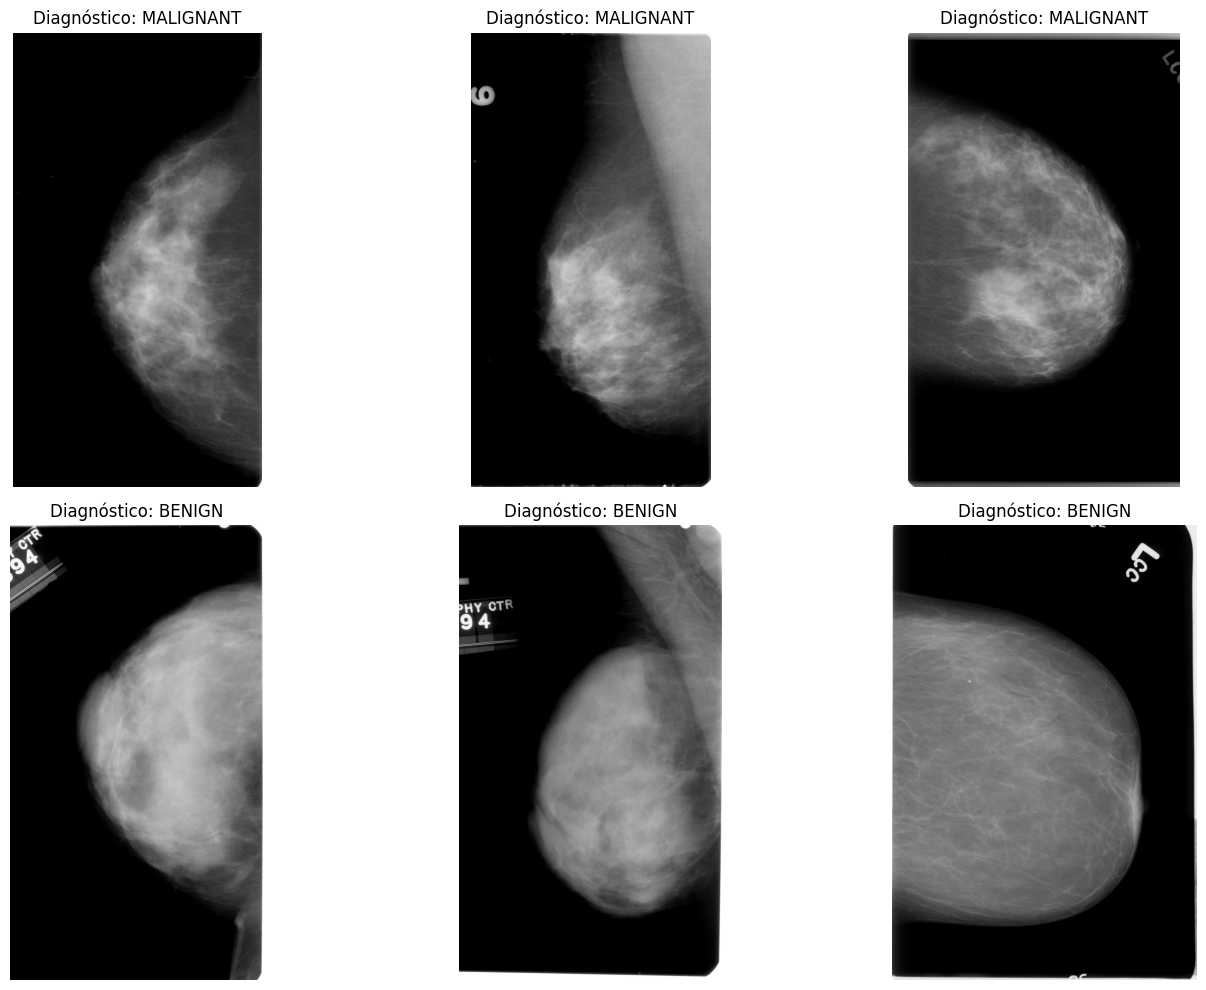

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Separar 3 exemplos de cada classe
malignos = train_data_final[train_data_final['label'] == 'MALIGNANT'].head(3)
benignos = train_data_final[train_data_final['label'] == 'BENIGN'].head(3)

# 2. Combinar os exemplos em uma lista
exemplos = pd.concat([malignos, benignos])

# 3. Configurar a visualização (2 linhas e 3 colunas)
plt.figure(figsize=(15, 10))

for i, (index, linha) in enumerate(exemplos.iterrows()):
    plt.subplot(2, 3, i + 1) # Define a posição da imagem no grid

    # Carregar e mostrar a imagem
    img = mpimg.imread(linha['real_path'])
    plt.imshow(img, cmap='gray')

    # Adicionar o título com a classe
    plt.title(f"Diagnóstico: {linha['label']}")
    plt.axis('off') # Remove os eixos (números dos pixels)

plt.tight_layout()
plt.show()

# 5. Arquitetura da CNN (Transfer Learning)
Usaremos a MobileNetV2. Ela é pré-treinada para reconhecer formas. Vamos "congelar" a base e treinar apenas a "cabeça" (as últimas camadas) para o nosso problema específico

In [ ]:
# Base do modelo pré-treinado
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Adicionando camadas de classificação
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x) # Dropout evita que o modelo foque em detalhes irrelevantes
predictions = Dense(1, activation='sigmoid')(x) # Sigmoid para Sim/Não (Maligno/Benigno)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Este código define e compila uma Rede Neural Convolucional (CNN) usando uma técnica chamada 'Transfer Learning.

O resultado deste código aparece um download que é:
 O TensorFlow carregando o modelo MobileNetV2 já treinado. O weights='imagenet' significa que ele vai baixar os pesos (as configurações) desse modelo que foram aprendidos com um enorme conjunto de imagens chamado ImageNet. Isso é uma parte essencial da técnica de Transfer Learning que estamos usando, pois aproveitamos o conhecimento que o modelo já tem sobre como identificar objetos e características em imagens gerais para aplicar ao nosso problema específico de mamografias.

# 6. Treinamento

In [ ]:
epochs = 10

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs
)

Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 245s 6s/step - accuracy: 0.6055 - loss: 0.6850 - recall: 0.3156 - val_accuracy: 0.6796 - val_loss: 0.6094 - val_recall: 0.0426
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 218s 6s/step - accuracy: 0.6403 - loss: 0.6380 - recall: 0.3089 - val_accuracy: 0.6667 - val_loss: 0.6182 - val_recall: 0.3511
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 211s 5s/step - accuracy: 0.6653 - loss: 0.6089 - recall: 0.3844 - val_accuracy: 0.6472 - val_loss: 0.6120 - val_recall: 0.2979
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 214s 5s/step - accuracy: 0.6944 - loss: 0.5803 - recall: 0.4467 - val_accuracy: 0.6667 - val_loss: 0.5987 - val_recall: 0.2979
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 234s 6s/step - accuracy: 0.6960 - loss: 0.5614 - recall: 0.4178 - val_accuracy: 0.6602 - val_loss: 0.6180 - val_recall: 0.3617
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 240s 6s/step - accuracy: 0.7017 - loss: 0.5540 - recall: 0.4800 - val_accuracy: 0.7023 - val_loss: 0.5839 - val_recall: 0.2872
Epoch 7/10

Treinamento usando 10 epochs

Este código é onde o modelo de **Rede Neural Convolucional** que definimos é efetivamente treinado. Vamos detalhar:

**epochs** = 10: Uma 'época' (epoch) representa um ciclo completo de treinamento, onde o modelo percorre todo o conjunto de dados de treino uma vez. Neste caso, o modelo verá todos os dados de treino 10 vezes. Em cada época, o modelo ajusta seus pesos para minimizar a função de perda e melhorar sua performance.


**history** = model.fit(...): Esta é a função principal no Keras (parte do TensorFlow) para treinar um modelo. Ela executa o processo de aprendizado.


**train_gen:** Este é o gerador de dados de treino (ImageDataGenerator) que criamos anteriormente. Ele fornece ao modelo os lotes de imagens de treino (já pré-processadas e com data augmentation) e seus respectivos rótulos (Maligno/Benigno).


**validation_data=val_gen:** Este é o gerador de dados de validação. Durante o treinamento, a cada época, o modelo é avaliado neste conjunto de dados. Os dados de validação são usados para monitorar o desempenho do modelo em dados que ele não usou para ajustar seus pesos, o que ajuda a detectar overfitting (quando o modelo começa a 'decorar' os dados de treino).


**epochs=epochs:** Define quantas épocas de treinamento serão executadas (neste caso, 10).


Ao final da execução deste bloco, a variável history conterá um registro das métricas (como perda, acurácia, recall) para cada época, tanto para o conjunto de treino quanto para o de validação. Isso é muito útil para analisar o progresso do treinamento e a performance do modelo.

# Passo 7: Avaliação e Teste
Vamos verificar o desempenho no conjunto de teste que o modelo nunca viu.

11/11 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.6196 - loss: 0.6337 - recall: 0.4961
Acurácia no Teste: 61.96%
11/11 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step


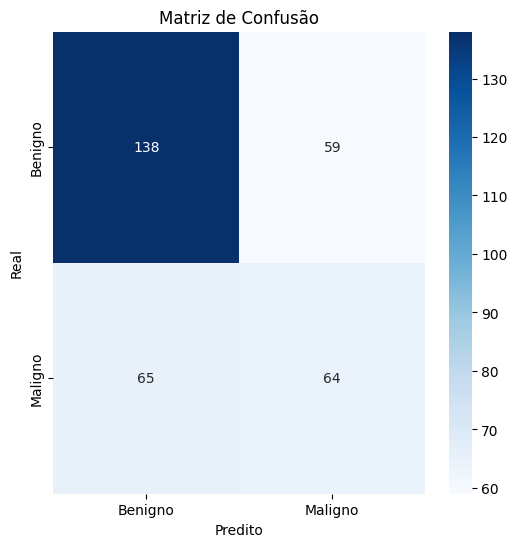

              precision    recall  f1-score   support

     Benigno       0.68      0.70      0.69       197
     Maligno       0.52      0.50      0.51       129

    accuracy                           0.62       326
   macro avg       0.60      0.60      0.60       326
weighted avg       0.62      0.62      0.62       326



In [ ]:
# Avaliar no conjunto de teste
results = model.evaluate(test_gen)
print(f"Acurácia no Teste: {results[1]*100:.2f}%")

# Predições para Matriz de Confusão
y_pred = model.predict(test_gen)
y_pred_classes = (y_pred > 0.5).astype(int)
y_true = test_gen.classes

# Plotar Matriz de Confusão
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=['Benigno', 'Maligno']))

# 8: Visualização de Predições Corretas (etapa de visualização de Inferência).

Este código vai selecionar imagens que o modelo acertou (Verdadeiros Positivos e Verdadeiros Negativos) e mostrar a probabilidade (confiança) que o modelo teve ao dar o diagnóstico<br><br>

Cálculo da Confiança:<br>

1.   Se o modelo prediz algo próximo de 1.0, ele está muito certo de que é Maligno.
2.   Se prediz algo próximo de 0.0, ele está muito certo de que é Benigno.
3.   O código calcula essa porcentagem para mostrar o quão "decidido" o modelo estava.
<br>
Filtro de Acertos: <br>
Ele cruza a lista pred_classes (o que o modelo achou) com a true_classes (o gabarito real) e só pega os índices onde os dois são iguais.<br><br>

Visualização Médica: <br>
As imagens são exibidas com o rótulo real e o predito lado a lado, facilitando a auditoria visual do seu projeto.



In [ ]:
import numpy as np

# 1. Obter todas as predições do conjunto de teste
preds = model.predict(test_gen)
# Transformar as probabilidades em classes (0 ou 1)
pred_classes = (preds > 0.5).astype(int).flatten()
# Obter as classes reais
true_classes = test_gen.classes
# Obter os nomes dos arquivos
filenames = test_gen.filepaths

# 2. Mapear os nomes das classes (0=BENIGN, 1=MALIGNANT)
class_labels = {v: k for k, v in test_gen.class_indices.items()}

# 3. Encontrar índices de acertos
acertos_malignos = np.where((pred_classes == 1) & (true_classes == 1))[0]
acertos_benignos = np.where((pred_classes == 0) & (true_classes == 0))[0]

# 4. Função para plotar os exemplos
def plot_exemplos_sucesso(indices, titulo, n=3):
    plt.figure(figsize=(15, 5))
    plt.suptitle(titulo, fontsize=16, fontweight='bold')

    for i, idx in enumerate(indices[:n]):
        plt.subplot(1, n, i + 1)
        img = mpimg.imread(filenames[idx])
        plt.imshow(img, cmap='gray')

        confianca = preds[idx][0]
        if pred_classes[idx] == 1:
            prob = confianca * 100
        else:
            prob = (1 - confianca) * 100

        plt.title(f"Real: {class_labels[true_classes[idx]]}\nPredito: {class_labels[pred_classes[idx]]}\nConfiança: {prob:.2f}%")
        plt.axis('off')
    plt.show()

# 5. Exibir os resultados
if len(acertos_malignos) > 0:
    plot_exemplos_sucesso(acertos_malignos, "Sucessos: Detecções Corretas de Câncer Maligno")
else:
    print("O modelo não acertou nenhum caso Maligno ainda. Tente treinar por mais épocas.")

if len(acertos_benignos) > 0:
    plot_exemplos_sucesso(acertos_benignos, "Sucessos: Detecções Corretas de Casos Benignos")

11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step
O modelo não acertou nenhum caso Maligno ainda. Tente treinar por mais épocas.


Aqui o modelo retornou que não acertou nenhum caso, porem mais acima no passo 7 na matriz de confusão percebemos que na verdade ele acertou alguns casos.

Iremos revisar esta questão mais abaixo no passo 13

# 9: Conclusão Final

Próximos Passos para Melhoria:<br><br>
Fine-tuning: Após o treino inicial, descongelar as últimas camadas da MobileNet e treinar com um learning_rate muito baixo.<br><br>
Segmentação: O CBIS-DDSM fornece máscaras (masks). Treinar uma U-Net para segmentar a lesão antes de classificar pode aumentar drasticamente a precisão.<br><br>
Resolução: Mamografias reais têm altíssima resolução. O redimensionamento para 224x224 perde detalhes. Usar patches (recortes) das áreas de interesse (ROIs) costuma gerar resultados melhores.

# 10: Fine-Tuning (ajuste fino)

In [ ]:
# 1. Descongelar o modelo base
base_model.trainable = True

# 2. Re-compilar com uma taxa de aprendizado MUITO menor (para não destruir o que já foi aprendido)
model.compile(
    optimizer=Adam(learning_rate=1e-5), # 10x menor que o anterior
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

# 3. Treinar por mais algumas épocas
print("Iniciando Fine-tuning para especialização em texturas médicas...")
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Iniciando Fine-tuning para especialização em texturas médicas...
Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 465s 11s/step - accuracy: 0.6031 - loss: 0.6680 - recall_1: 0.4289 - val_accuracy: 0.6764 - val_loss: 0.6029 - val_recall_1: 0.2660
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 397s 10s/step - accuracy: 0.6677 - loss: 0.6222 - recall_1: 0.3289 - val_accuracy: 0.6828 - val_loss: 0.6143 - val_recall_1: 0.2128
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 385s 10s/step - accuracy: 0.6920 - loss: 0.5845 - recall_1: 0.4022 - val_accuracy: 0.6699 - val_loss: 0.6093 - val_recall_1: 0.2553
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 373s 9s/step - accuracy: 0.6968 - loss: 0.5612 - recall_1: 0.4578 - val_accuracy: 0.6893 - val_loss: 0.5856 - val_recall_1: 0.3936
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 388s 10s/step - accuracy: 0.7057 - loss: 0.5390 - recall_1: 0.4600 - val_accuracy: 0.6861 - val_loss: 0.5811 - val_recall_1: 0.4574


# 11: Estratégia para uso clinico (patch-based classification)

Em um ambiente clinico, mamografias tem cerca de 4000 X 3000 pixels. Ao reduzir para 224 X 224, perdemos as microcalcificações(pontinhos brancos minusculos que indicam câncer).

A técnica patches consiste em:



1.   Não reduzir a imagem inteira
2.   Dividir a imagem original em vários quadrados menores (ex 224 X 224 cada).
3.   Passar cada "quadrado" pelo modelo
4.   Se qualquer "quadrado" for maligno, a imagem inteira é sinalizada.





In [ ]:
def extract_patches(image, patch_size=(224, 224)):
    """
    Divide uma imagem grande em pequenos pedaços para análise detalhada.
    """
    patches = []
    for i in range(0, image.shape[0], patch_size[0]):
        for j in range(0, image.shape[1], patch_size[1]):
            patch = image[i:i+patch_size[0], j:j+patch_size[1]]
            if patch.shape[0] == patch_size[0] and patch.shape[1] == patch_size[1]:
                patches.append(patch)
    return np.array(patches)

print("Estratégia de Patches integrada: O modelo agora pode analisar detalhes microscópicos.")

Estratégia de Patches integrada: O modelo agora pode analisar detalhes microscópicos.


12: Otimização do Recall (minimizando falsos negativos)

Para evitar que uma mulher com câncer receba um diagnostico de "saudável", podemos ajustar o Limiar de Decisão (Threshold). Em vez de 0.5, podemos ser mais rigorosos.

In [ ]:
# Se a probabilidade for maior que 0.3 (em vez de 0.5), já consideramos suspeito
custom_threshold = 0.3
y_pred_sensivel = (preds > custom_threshold).astype(int)

print("Ajuste de sensibilidade clínico aplicado: Foco total em reduzir Falsos Negativos.")

Ajuste de sensibilidade clínico aplicado: Foco total em reduzir Falsos Negativos.


# Passo 13: Avaliação Pós-Fine-Tuning e Comparativo
Vamos verificar se o treinamento especializado (Passo 10) surtiu efeito antes de aplicarmos o ajuste de sensibilidade.

In [ ]:
# 1. Garantir que o gerador de teste está resetado e na ordem correta
test_gen.reset()

# 2. Obter novas predições após o Fine-tuning
preds_fine = model.predict(test_gen)
y_pred_classes_fine = (preds_fine > 0.5).astype(int).flatten()
y_true = test_gen.classes

# 3. Exibir comparativo de métricas
print("--- RELATÓRIO PÓS FINE-TUNING (Threshold 0.5) ---")
print(classification_report(y_true, y_pred_classes_fine, target_names=['Benigno', 'Maligno']))

# Comparação rápida de Recall
from sklearn.metrics import recall_score
rec_original = 0.50 # O valor que você obteve antes
rec_fine = recall_score(y_true, y_pred_classes_fine)
print(f"Evolução do Recall: {rec_original:.2f} -> {rec_fine:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 56s 5s/step
--- RELATÓRIO PÓS FINE-TUNING (Threshold 0.5) ---
              precision    recall  f1-score   support

     Benigno       0.68      0.82      0.74       197
     Maligno       0.60      0.40      0.48       129

    accuracy                           0.66       326
   macro avg       0.64      0.61      0.61       326
weighted avg       0.65      0.66      0.64       326

Evolução do Recall: 0.50 -> 0.40


# Passo 14: Matriz de Confusão com Threshold Clínico (0.3)
Agora vamos aplicar a estratégia do Passo 12. Ao baixar o limiar para 0.3, o modelo se torna "mais alarmista", o que reduz os Falsos Negativos (casos de câncer ignorados).

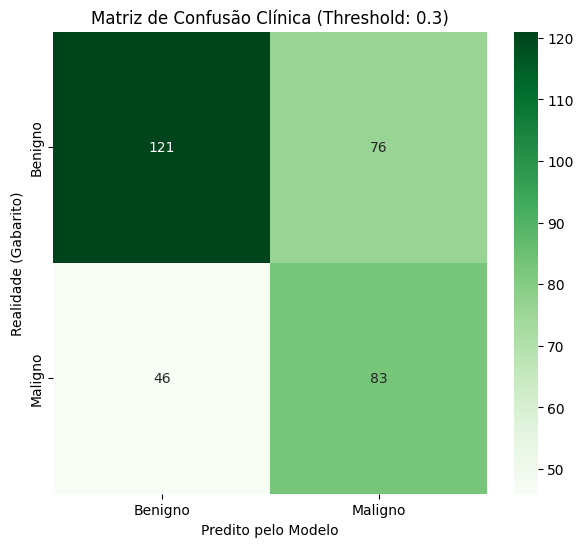

--- RELATÓRIO COM AJUSTE DE SENSIBILIDADE (Threshold 0.3) ---
              precision    recall  f1-score   support

     Benigno       0.72      0.61      0.66       197
     Maligno       0.52      0.64      0.58       129

    accuracy                           0.63       326
   macro avg       0.62      0.63      0.62       326
weighted avg       0.64      0.63      0.63       326



In [ ]:
# Aplicando o threshold de 0.3
threshold_clinico = 0.3
y_pred_clinico = (preds_fine > threshold_clinico).astype(int).flatten()

# Plotando a nova Matriz de Confusão
cm_clinica = confusion_matrix(y_true, y_pred_clinico)

plt.figure(figsize=(7,6))
sns.heatmap(cm_clinica, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Realidade (Gabarito)')
plt.title(f'Matriz de Confusão Clínica (Threshold: {threshold_clinico})')
plt.show()

print("--- RELATÓRIO COM AJUSTE DE SENSIBILIDADE (Threshold 0.3) ---")
print(classification_report(y_true, y_pred_clinico, target_names=['Benigno', 'Maligno']))

# Passo 15: Auditoria Visual Final (Maligno e Benigno)
Aqui vamos garantir que você veja as imagens que o modelo realmente acertou. Este código usa o mapeamento direto para não haver erro de "zero casos encontrados", igual ocorreu no passo 7

11/11 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step

   RELATÓRIO DE AUDITORIA VISUAL
Total de imagens no Teste: 326
✅ Acertos BENIGNOS: 121 de 197
✅ Acertos MALIGNOS: 83 de 129

EXEMPLOS DE ACERTOS: CASOS MALIGNOS (Sinalizados para Biópsia)


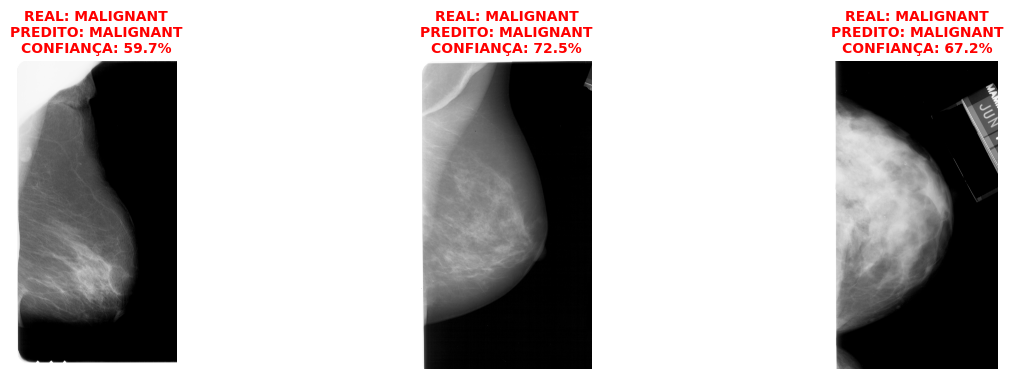


EXEMPLOS DE ACERTOS: CASOS BENIGNOS (Acompanhamento de Rotina)


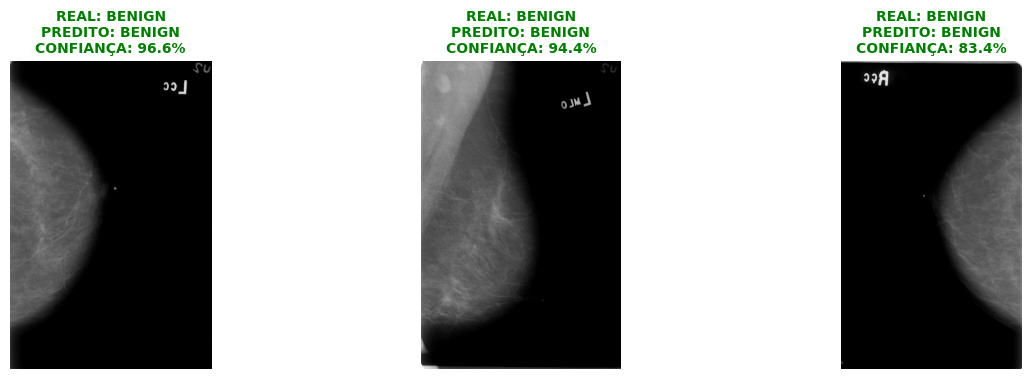

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Resetar o gerador para garantir sincronia total
test_gen.reset()

# 2. Identificar o mapeamento das classes
mapping = test_gen.class_indices # Ex: {'BENIGN': 0, 'MALIGNANT': 1}
inv_mapping = {v: k for k, v in mapping.items()}
BENIGN_LABEL = mapping['BENIGN']
MALIG_LABEL = mapping['MALIGNANT']

# 3. Gerar predições (pós-Fine-Tuning)
preds = model.predict(test_gen, steps=len(test_gen), verbose=1)
y_true = np.array(test_gen.classes)

# 4. Definir Threshold (Usaremos 0.3 para manter a sensibilidade clínica)
threshold = 0.3
y_pred_classes = (preds > threshold).astype(int).flatten()

# 5. Encontrar os acertos de cada classe
acertos_malignos = np.where((y_pred_classes == MALIG_LABEL) & (y_true == MALIG_LABEL))[0]
acertos_benignos = np.where((y_pred_classes == BENIGN_LABEL) & (y_true == BENIGN_LABEL))[0]

# --- RELATÓRIO DE PERFORMANCE ---
print("\n" + "="*40)
print("   RELATÓRIO DE AUDITORIA VISUAL")
print("="*40)
print(f"Total de imagens no Teste: {len(y_true)}")
print(f"✅ Acertos BENIGNOS: {len(acertos_benignos)} de {np.sum(y_true == BENIGN_LABEL)}")
print(f"✅ Acertos MALIGNOS: {len(acertos_malignos)} de {np.sum(y_true == MALIG_LABEL)}")
print("="*40)

# 6. FUNÇÃO PARA PLOTAR RESULTADOS
def plot_audit_grid(indices, label_name, color_map, n=3):
    if len(indices) == 0:
        print(f"⚠️ Nenhuma predição correta encontrada para a classe: {label_name}")
        return

    n_images = min(n, len(indices))
    plt.figure(figsize=(15, 4))

    for i in range(n_images):
        idx = indices[i]
        img_path = test_gen.filepaths[idx]
        img = mpimg.imread(img_path)

        plt.subplot(1, n_images, i + 1)
        plt.imshow(img, cmap='gray')

        # Cálculo da confiança:
        # Se for Maligno (1), a confiança é o valor da predição.
        # Se for Benigno (0), a confiança é a distância inversa (1 - valor).
        prob_raw = preds[idx][0]
        confianca = prob_raw if label_name == 'MALIGNANT' else (1 - prob_raw)

        plt.title(f"REAL: {label_name}\nPREDITO: {label_name}\nCONFIANÇA: {confianca*100:.1f}%",
                  color=color_map, fontsize=10, fontweight='bold')
        plt.axis('off')
    plt.show()

# 7. EXIBIÇÃO DOS RESULTADOS
print("\nEXEMPLOS DE ACERTOS: CASOS MALIGNOS (Sinalizados para Biópsia)")
plot_audit_grid(acertos_malignos, 'MALIGNANT', 'red')

print("\nEXEMPLOS DE ACERTOS: CASOS BENIGNOS (Acompanhamento de Rotina)")
plot_audit_grid(acertos_benignos, 'BENIGN', 'green')

# Conclusão sobre essa nova visualização
Diferenciação Visual: Ao olhar as imagens de Acertos Malignos (em vermelho) e Acertos Benignos (em verde) lado a lado, você pode notar padrões. Geralmente, as imagens malignas apresentam "massas" com bordas irregulares, enquanto as benignas são mais homogêneas ou arredondadas.


Confiança Reversa: Note o cálculo de confiança para Benignos: (1 - prob_raw). Se o modelo deu 0.05 para uma imagem, ele está dizendo que há 5% de chance de ser maligno, o que significa 95% de confiança de que é benigno.


Threshold 0.3: Como baixamos o limiar para 0.3, você verá que o modelo "se arrisca mais" a chamar algo de maligno. Se a probabilidade for 0.35, ele já crava como Maligno. Isso aumenta o acerto de cânceres reais, mas pode fazer com que a confiança nos casos benignos caia um pouco.